# The Inverse Problem
Note: the procedures we are going to apply are correct in the thermodynamics limit (an infinite time series). Indeed, we can see that the results are all incorrect!

In [75]:
library(igraph)
library(ggplot2)
library(RColorBrewer)
library(rgl)

set.seed(0)

## White Noise Model
### Threshold procedure

In [76]:
N <- 100 # number of nodes
M <- 10000 # number of time steps
thresholds <- seq(0.1, 1, 0.1)

mean_val <- 0
std_val <- 1

all_data <- rnorm(N * M, mean = mean_val, sd = std_val)
signals <- matrix(all_data, nrow = M, ncol = N)

In [77]:
is_identity <- function(mat) {  
  identity <- diag(N)
  return(isTRUE(all.equal(mat, identity)))
}

correlations <- abs(cor(signals))

white_dict <- list()

for (i in seq_along(thresholds)) {
  thr <- thresholds[i]
  key <- paste0("thr_", thr)
  white_dict[[key]] <- ifelse(correlations >= thr, yes=1, no=0)
  state <- is_identity(white_dict[[key]])
  cat("Thr =", thr, ", Is Identity?", state, "\n")
}

# print(white_dict[['thr_0.1']])

Thr = 0.1 , Is Identity? TRUE 
Thr = 0.2 , Is Identity? TRUE 
Thr = 0.3 , Is Identity? TRUE 
Thr = 0.4 , Is Identity? TRUE 
Thr = 0.5 , Is Identity? TRUE 
Thr = 0.6 , Is Identity? TRUE 
Thr = 0.7 , Is Identity? TRUE 
Thr = 0.8 , Is Identity? TRUE 
Thr = 0.9 , Is Identity? TRUE 
Thr = 1 , Is Identity? TRUE 


As expected, there is no correlation between nodes as the time series are given by gaussian white noise

### Comparison with null model

In [78]:
construct_probmatrix <- function(signals, K=100) {

    # we build  the correlation matrix
    correlations <- cor(signals)

    # we initialize a tensor NxNxK in which we put K shuffled signals for each time series
    surrogate_array <- array(0, dim = c(N, N, K))

    for (k in 1:K) {
        # we shuffle each time series and calculate its correlation matrix
        surrogate_signals <- matrix(0, nrow = M, ncol = N)
        for (i in 1:N) {
            surrogate_signals[, i] <- sample(signals[, i])
        }
        surrogate_correlations <- cor(surrogate_signals)

        # we save the shuffled matrix in k index
        surrogate_array[,,k] <- surrogate_correlations
    }

    # we calculate mean and sd along the k direction (pointwise, over the k shuffled time series)
    mean_mat <- apply(surrogate_array, MARGIN = c(1, 2), FUN = mean)
    sd_mat <- apply(surrogate_array, MARGIN = c(1, 2), FUN = sd)

    z_scores <- (correlations - mean_mat) / sd_mat
    diag(z_scores) <- 0 # to correct Nan due to division by zero

    probability_mat <- 2*(1 - pnorm(abs(z_scores)))
    
    return(probability_mat)

}


is_zero <- function(mat) {
  return(sum(mat) == 0)
}


get_adjmatrix <- function(prob_matrix, thresholds_pvalue, print=TRUE) {

    dict <- list()

    for (i in seq_along(thresholds_pvalue)) {
        thr <- thresholds_pvalue[i]
        key <- paste0("thr_", thr)
        dict[[key]] <- ifelse(prob_matrix <= thr, yes=1, no=0) # different from before, as we are dealing with p-values
        if (print==TRUE) {
            state <- is_zero(dict[[key]])
            cat("Thr =", thr, ", Is empty graph?", state, "\n")
        }
    }

    return(dict)

}

In [79]:
thresholds_pvalue <- c(0.001, 0.01, 0.05, 0.1, 0.5)

prob_mat <- construct_probmatrix(signals, K=100)
print(prob_mat)

               [,1]        [,2]        [,3]       [,4]        [,5]        [,6]
  [1,] 1.0000000000 0.397452851 0.853808563 0.64998378 0.494174286 0.914804905
  [2,] 0.3974528510 1.000000000 0.399132347 0.02584349 0.668467294 0.406035989
  [3,] 0.8538085632 0.399132347 1.000000000 0.45112518 0.008722545 0.193124423
  [4,] 0.6499837801 0.025843495 0.451125176 1.00000000 0.362168299 0.719469130
  [5,] 0.4941742864 0.668467294 0.008722545 0.36216830 1.000000000 0.365112998
  [6,] 0.9148049048 0.406035989 0.193124423 0.71946913 0.365112998 1.000000000
  [7,] 0.2388272135 0.341179362 0.938677800 0.36012336 0.477451398 0.052586727
  [8,] 0.4938720693 0.029298504 0.018062515 0.89927005 0.805605043 0.309551962
  [9,] 0.5254418888 0.318048632 0.036820811 0.66265594 0.414695574 0.270257992
 [10,] 0.4235672966 0.886000571 0.283400440 0.69180957 0.434167805 0.172980467
 [11,] 0.0423928131 0.282944740 0.492901264 0.89342329 0.353172575 0.107075960
 [12,] 0.8106468150 0.638671461 0.257036722 0.713493

In [80]:
adj_mat <- get_adjmatrix(prob_mat, thresholds_pvalue, print=TRUE)
print(adj_mat[1])

Thr = 0.001 , Is empty graph? FALSE 
Thr = 0.01 , Is empty graph? FALSE 
Thr = 0.05 , Is empty graph? FALSE 
Thr = 0.1 , Is empty graph? FALSE 
Thr = 0.5 , Is empty graph? FALSE 


$thr_0.001
       [,1] [,2] [,3] [,4] [,5] [,6] [,7] [,8] [,9] [,10] [,11] [,12] [,13]
  [1,]    0    0    0    0    0    0    0    0    0     0     0     0     0
  [2,]    0    0    0    0    0    0    0    0    0     0     0     0     0
  [3,]    0    0    0    0    0    0    0    0    0     0     0     0     0
  [4,]    0    0    0    0    0    0    0    0    0     0     0     0     0
  [5,]    0    0    0    0    0    0    0    0    0     0     0     0     0
  [6,]    0    0    0    0    0    0    0    0    0     0     0     0     0
  [7,]    0    0    0    0    0    0    0    0    0     0     0     0     0
  [8,]    0    0    0    0    0    0    0    0    0     0     0     0     0
  [9,]    0    0    0    0    0    0    0    0    0     0     0     0     0
 [10,]    0    0    0    0    0    0    0    0    0     0     0     0     0
 [11,]    0    0    0    0    0    0    0    0    0     0     0     0     0
 [12,]    0    0    0    0    0    0    0    0    0     0     0     0     0
 

Note: the pvalue tells us how much nodes are uncorrelated (in other words, how much they are similar to the mean value of correlations which should be zero). So if nodes are highly correlated, like with P=1e-3, we set the correspondent element in adjacency matrix equal to one.

## Kuramoto Model
We use a Barabasi-Albert network

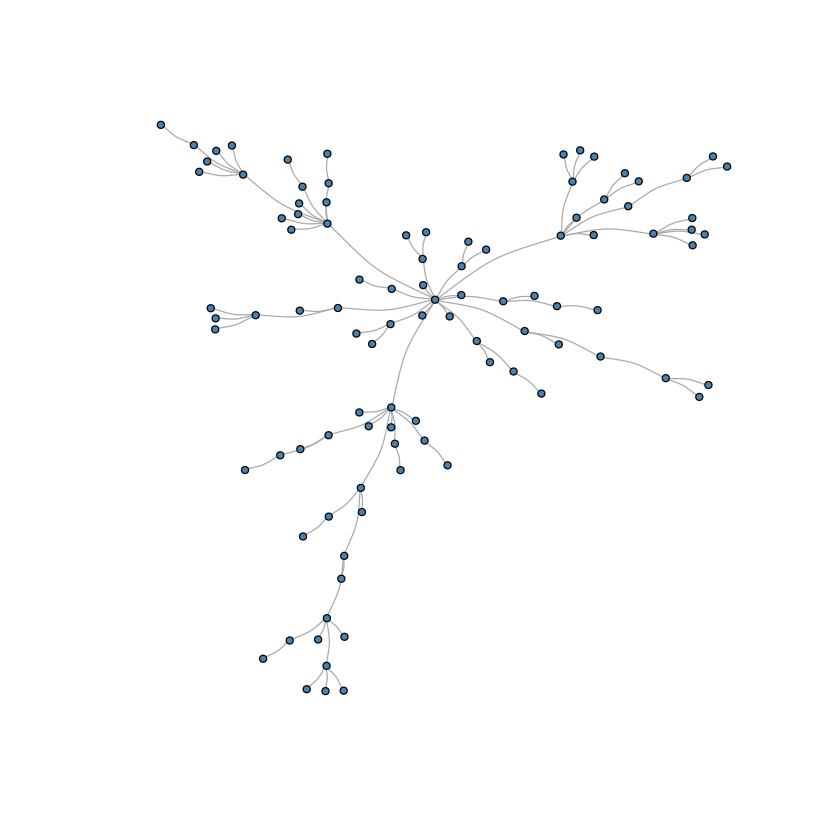

In [114]:
source('common.R')

g <- sample_pa(n=N, m=1, directed=FALSE)
E(g)$weight <- 1
lay <- layout_with_fr(g)
plot(g, layout=lay, vertex.color="steelblue", vertex.label=NA, edge.curved=0.2, vertex.size=2.5)

true_adjacency_mat <- as_adjacency_matrix(g, sparse = FALSE)
# print(true_adjacency_mat)

In [130]:
timeseries <- KURAMOTO(g, size=M, sd.meas.noise=0., sigma=1)

# matrix transformation (as in the previous format)
signals_raw_matrix <- do.call(cbind, timeseries)

# as phases could be infinite, we evaluate the sine of the signals to calculate correlations
signals <- sin(signals_raw_matrix)

prob_mat <- construct_probmatrix(signals, K = 100)
print(prob_mat)

               [,1]         [,2]         [,3]         [,4]         [,5]
  [1,] 1.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  [2,] 0.000000e+00 1.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  [3,] 0.000000e+00 0.000000e+00 1.000000e+00 0.000000e+00 0.000000e+00
  [4,] 0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00 0.000000e+00
  [5,] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00
  [6,] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  [7,] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  [8,] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  [9,] 0.000000e+00 0.000000e+00 0.000000e+00 1.094446e-07 0.000000e+00
 [10,] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [11,] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [12,] 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 [13,] 0.000000e+00 0.000000e+00 2.857714e-13 0.000000e+00 0.000

In [121]:
thresholds_pvalue <- c(0.001, 0.01, 0.05, 0.1, 0.5)
adj_mat <- get_adjmatrix(prob_mat, thresholds_pvalue, print = FALSE)

for (i in seq_along(thresholds_pvalue)) {
    state <- isTRUE(all.equal(adj_mat[i], true_adjacency_mat))
    cat("Thr =", thr, ", Is equal to true adj_matrix?", state, "\n")
}


Thr = 1 , Is equal to true adj_matrix? FALSE 
Thr = 1 , Is equal to true adj_matrix? FALSE 
Thr = 1 , Is equal to true adj_matrix? FALSE 
Thr = 1 , Is equal to true adj_matrix? FALSE 
Thr = 1 , Is equal to true adj_matrix? FALSE 


This method does not farnish the right adjacency matrix. We can see this also by printing the found ones.

In [128]:
print(true_adjacency_mat)

       [,1] [,2] [,3] [,4] [,5] [,6] [,7] [,8] [,9] [,10] [,11] [,12] [,13]
  [1,]    0    1    0    0    0    0    0    1    1     0     1     0     1
  [2,]    1    0    1    1    1    1    1    0    0     0     0     0     0
  [3,]    0    1    0    0    0    0    0    0    0     0     0     0     0
  [4,]    0    1    0    0    0    0    0    0    0     1     0     0     0
  [5,]    0    1    0    0    0    0    0    0    0     0     0     0     0
  [6,]    0    1    0    0    0    0    0    0    0     0     0     0     0
  [7,]    0    1    0    0    0    0    0    0    0     0     0     0     0
  [8,]    1    0    0    0    0    0    0    0    0     0     0     0     0
  [9,]    1    0    0    0    0    0    0    0    0     0     0     0     0
 [10,]    0    0    0    1    0    0    0    0    0     0     0     0     0
 [11,]    1    0    0    0    0    0    0    0    0     0     0     1     0
 [12,]    0    0    0    0    0    0    0    0    0     0     1     0     0
 [13,]    1 

In [127]:
print(adj_mat[3])

$thr_0.05
       [,1] [,2] [,3] [,4] [,5] [,6] [,7] [,8] [,9] [,10] [,11] [,12] [,13]
  [1,]    0    1    1    1    1    1    1    1    1     1     1     1     1
  [2,]    1    0    1    1    1    1    1    1    1     1     0     1     1
  [3,]    1    1    0    1    1    1    1    1    1     1     1     1     1
  [4,]    1    1    1    0    1    1    1    1    1     1     1     1     1
  [5,]    1    1    1    1    0    1    1    1    1     1     1     1     1
  [6,]    1    1    1    1    1    0    1    1    1     1     1     1     1
  [7,]    1    1    1    1    1    1    0    1    1     1     1     1     1
  [8,]    1    1    1    1    1    1    1    0    1     1     1     1     1
  [9,]    1    1    1    1    1    1    1    1    0     1     1     1     1
 [10,]    1    1    1    1    1    1    1    1    1     0     1     1     1
 [11,]    1    0    1    1    1    1    1    1    1     1     0     1     1
 [12,]    1    1    1    1    1    1    1    1    1     1     1     0     1
 [